In [2]:
import tensorflow as tf

# Jurus biar TensorFlow nggak serakah makan semua VRAM sekaligus
gpus = tf.config.list_physical_devices('GPU')
if gpus:
  try:
    for gpu in gpus:
      tf.config.experimental.set_memory_growth(gpu, True)
    print("GPU Memory Growth Enabled: AMAN!")
  except RuntimeError as e:
    print(e)

Physical devices cannot be modified after being initialized


# 1. Import Library & Setup Environment


In [3]:
import os, random, numpy as np, pandas as pd, matplotlib.pyplot as plt
import tensorflow as tf
from PIL import Image
from tensorflow.keras import layers, models

# Cek Versi & GPU
print(f"TensorFlow Version: {tf.__version__}")
print("GPU Ditemukan:" if tf.config.list_physical_devices('GPU') else "GPU Tidak Ada")

TensorFlow Version: 2.20.0
GPU Ditemukan:


# 2. Data Preparation & Loading

In [ ]:
# Path folder
train_dir = 'Apple_Disease_Dataset/train'

# Kamus gambar buat EDA
class_names = os.listdir(train_dir)
apple_images = {class_name: os.listdir(os.path.join(train_dir, class_name)) for class_name in class_names}

# 3. Dataset Checking (EDA - Visualisasi 5 Gambar)

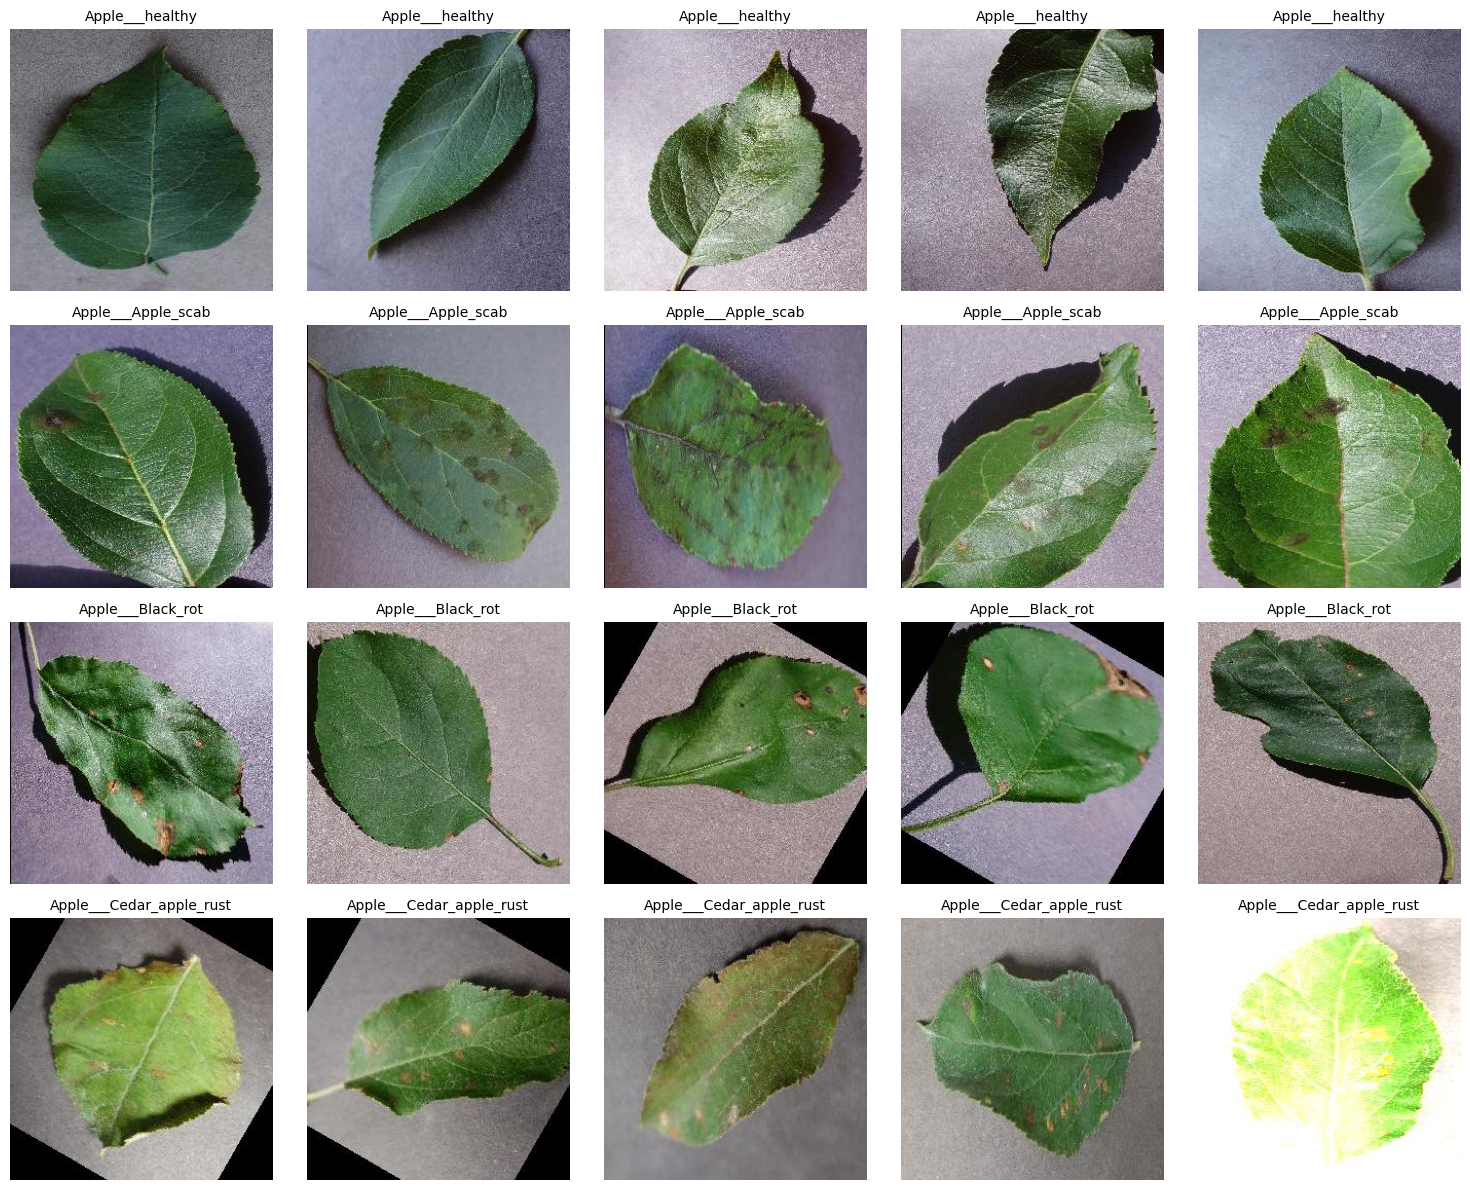

In [5]:
fig, axs = plt.subplots(len(apple_images.keys()), 5, figsize=(15, 12))
for i, class_name in enumerate(apple_images.keys()):
    random_images = random.sample(apple_images[class_name], 5)
    for j, image_name in enumerate(random_images):
        img_path = os.path.join(train_dir, class_name, image_name)
        img = Image.open(img_path)
        axs[i, j].imshow(img)
        axs[i, j].set_title(class_name, fontsize=10)
        axs[i, j].axis('off')
plt.tight_layout()
plt.show()

# 4. Plot Distribusi (Analisis Data Scientist)

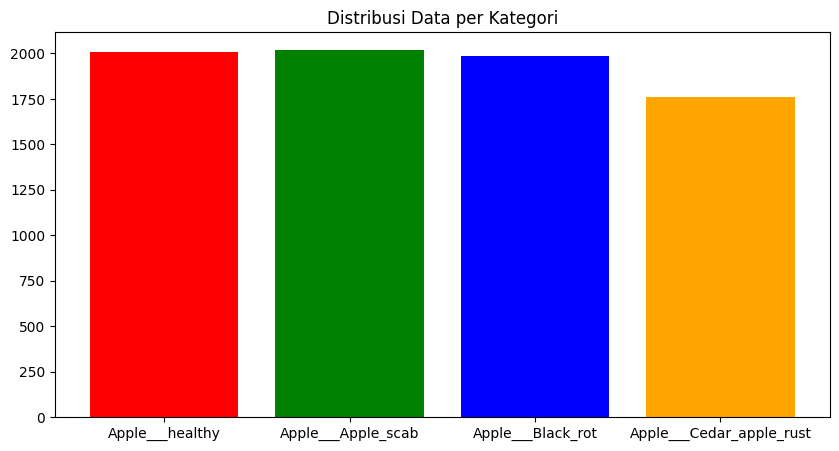

In [6]:
counts = [len(apple_images[c]) for c in class_names]
plt.figure(figsize=(10, 5))
plt.bar(class_names, counts, color=['red', 'green', 'blue', 'orange'])
plt.title('Distribusi Data per Kategori')
plt.show()

# 5. Data Pipeline (Prefetch & Cache)

In [7]:
train_dataset = tf.keras.utils.image_dataset_from_directory(
    train_dir, validation_split=0.2, subset="training", seed=123,
    image_size=(224, 224), 
    batch_size=8,
    label_mode='categorical'
)

val_dataset = tf.keras.utils.image_dataset_from_directory(
    train_dir, validation_split=0.2, subset="validation", seed=123,
    image_size=(224, 224), 
    batch_size=8,
    label_mode='categorical'
)

Found 7771 files belonging to 4 classes.
Using 6217 files for training.
Found 7771 files belonging to 4 classes.
Using 1554 files for validation.


In [8]:
AUTOTUNE = tf.data.AUTOTUNE
train_dataset = train_dataset.prefetch(AUTOTUNE)
val_dataset = val_dataset.prefetch(AUTOTUNE)


# 6. Build Model CNN + Augmentation

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.applications import MobileNetV2

# AUGMENTASI (cukup satu aja, jangan dobel)
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.2),
])

# LOAD BASE MODEL MobileNetV2
base_model = MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)

base_model.trainable = False  # kunci base model biar gak berat

# BUILD MODEL
model = tf.keras.Sequential([
    layers.Input(shape=(224, 224, 3)),
    data_augmentation,
    layers.Rescaling(1./255),

    base_model,

    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.3),
    layers.Dense(4, activation='softmax')
])

# COMPILE MODEL
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_2 (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_1 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │         5,124 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,263,108 (8.63 MB)

 Trainable params: 5,124 (20.02 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

# 7. Training & Evaluasi (The "Learning")

In [10]:
# 7. Training Model "Sultan"
# Bersihin graph lama (penting kalau sering run ulang di notebook)
tf.keras.backend.clear_session()

# Callback Early Stopping
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=15,
    callbacks=[early_stop],✅ 1. SAVE MODEL
    verbose=1
)

Epoch 1/15


2026-02-19 17:53:38.213485: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91900


778/778 ━━━━━━━━━━━━━━━━━━━━ 32s 35ms/step - accuracy: 0.8655 - loss: 0.3665 - val_accuracy: 0.9607 - val_loss: 0.1248
Epoch 2/15
778/778 ━━━━━━━━━━━━━━━━━━━━ 26s 34ms/step - accuracy: 0.9477 - loss: 0.1476 - val_accuracy: 0.9620 - val_loss: 0.1129
Epoch 3/15
778/778 ━━━━━━━━━━━━━━━━━━━━ 26s 34ms/step - accuracy: 0.9609 - loss: 0.1141 - val_accuracy: 0.9788 - val_loss: 0.0678
Epoch 4/15
778/778 ━━━━━━━━━━━━━━━━━━━━ 26s 34ms/step - accuracy: 0.9617 - loss: 0.1058 - val_accuracy: 0.9678 - val_loss: 0.0875
Epoch 5/15
778/778 ━━━━━━━━━━━━━━━━━━━━ 26s 34ms/step - accuracy: 0.9638 - loss: 0.1020 - val_accuracy: 0.9749 - val_loss: 0.0688
Epoch 6/15
778/778 ━━━━━━━━━━━━━━━━━━━━ 26s 34ms/step - accuracy: 0.9638 - loss: 0.1020 - val_accuracy: 0.9768 - val_loss: 0.0622
Epoch 7/15
778/778 ━━━━━━━━━━━━━━━━━━━━ 26s 34ms/step - accuracy: 0.9646 - loss: 0.0998 - val_accuracy: 0.9717 - val_loss: 0.0769
Epoch 8/15
778/778 ━━━━━━━━━━━━━━━━━━━━ 27s 35ms/step - accuracy: 0.9685 - loss: 0.0868 - val_accurac

#  SAVE MODEL

In [11]:
model.save("apple_disease_model.h5")
print("Model berhasil disimpan sebagai apple_disease_model.h5")


Model berhasil disimpan sebagai apple_disease_model.h5


# PLOT ACCURACY & LOSS

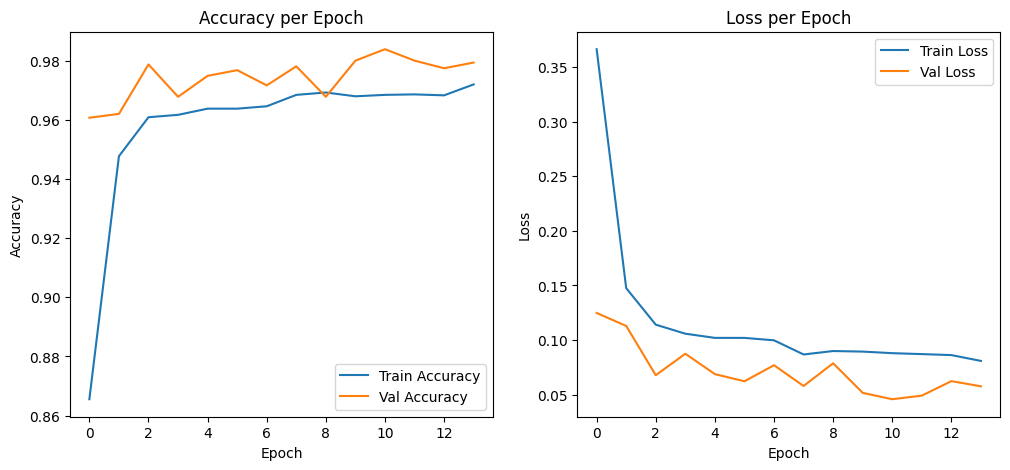

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title("Accuracy per Epoch")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

# Loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title("Loss per Epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()


# CONFUSION MATRIX + CLASSIFICATION REPORT

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 623ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━

2026-02-19 19:12:26.918524: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


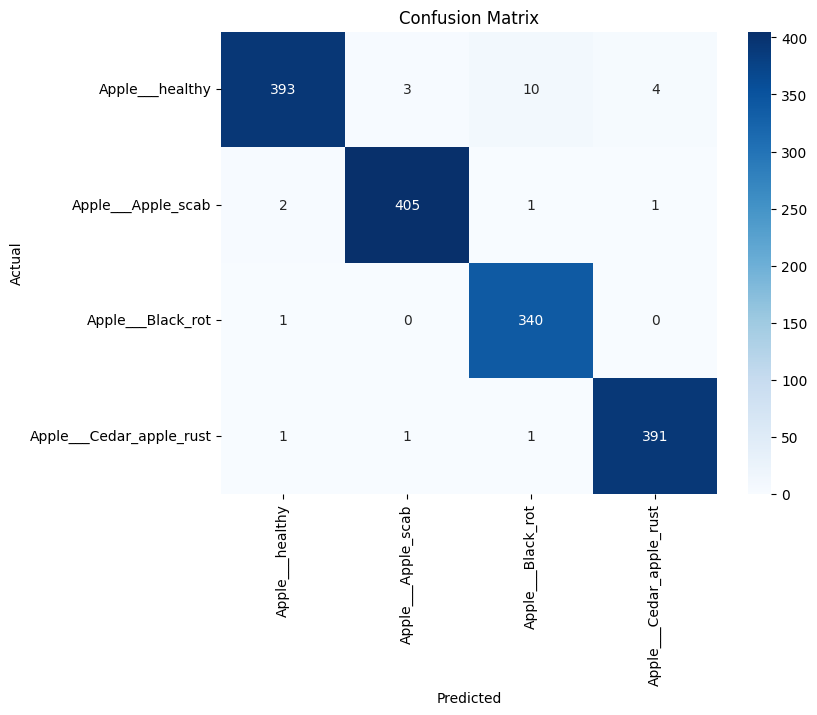

Classification Report:

                          precision    recall  f1-score   support

         Apple___healthy       0.99      0.96      0.97       410
      Apple___Apple_scab       0.99      0.99      0.99       409
       Apple___Black_rot       0.97      1.00      0.98       341
Apple___Cedar_apple_rust       0.99      0.99      0.99       394

                accuracy                           0.98      1554
               macro avg       0.98      0.98      0.98      1554
            weighted avg       0.98      0.98      0.98      1554



In [13]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# Ambil label asli dan prediksi
y_true = []
y_pred = []

for images, labels in val_dataset:
    preds = model.predict(images)
    y_true.extend(np.argmax(labels.numpy(), axis=1))
    y_pred.extend(np.argmax(preds, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Classification Report
print("Classification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_names))
